# Breast Cancer Prediction using Machine Learning

**Dataset:** Wisconsin Diagnostic Breast Cancer Dataset (569 patients, 10 cell-measurement features)
**Goal:** Predict whether a breast tumor is malignant (cancerous) or benign (not cancerous), based on measurements taken from a tissue sample (the kind of measurements a pathologist takes from a biopsy image).

This dataset comes built into the `scikit-learn` library, so it's already extremely clean — a nice contrast to the Diabetes and Heart Disease datasets, which both needed clean-up.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, ConfusionMatrixDisplay,
                              RocCurveDisplay)
import joblib

sns.set_theme(style="whitegrid", palette="viridis")
%matplotlib inline


## 1. Load the data

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # sklearn: 0 = malignant, 1 = benign
print(df.shape)
print("Classes:", data.target_names)
df.head()


(569, 31)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Pick a focused feature set

The full dataset has 30 features (mean, "standard error", and "worst" versions of 10 base measurements). To keep things interpretable — and to keep the web app's input form short enough for a person to fill in by hand — we'll use just the 10 **mean** measurements.

We also flip the label so `1` consistently means **"disease present"** (malignant) across all three of our disease checkers, matching Diabetes and Heart Disease.

In [3]:
selected_features = [
    "mean radius", "mean texture", "mean perimeter", "mean area",
    "mean smoothness", "mean compactness", "mean concavity",
    "mean concave points", "mean symmetry", "mean fractal dimension",
]

X = df[selected_features]
y = (df["target"] == 0).astype(int)  # 1 = malignant, 0 = benign

print("Missing values:", X.isnull().sum().sum())
print("Class balance:\n", y.value_counts())


Missing values: 0
Class balance:
 target
0    357
1    212
Name: count, dtype: int64


No missing values — this dataset needed no cleaning at all, which is rare and worth calling out explicitly.

## 3. Exploratory Data Analysis (EDA)

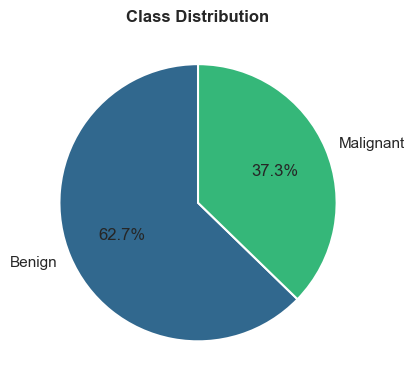

In [4]:
fig, ax = plt.subplots(figsize=(5, 4.5))
counts = y.value_counts().sort_index()
ax.pie(counts, labels=["Benign", "Malignant"], autopct="%1.1f%%",
       colors=sns.color_palette("viridis", 2), startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Class Distribution", fontweight="bold")
plt.show()


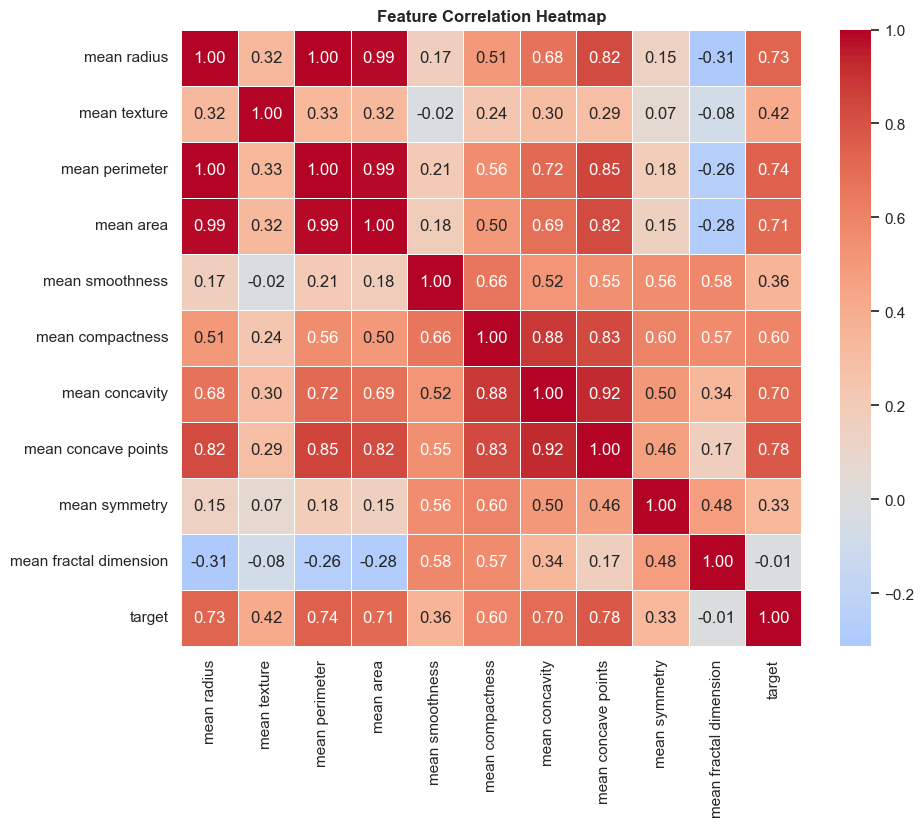

In [5]:
plot_df = X.copy()
plot_df["target"] = y
plt.figure(figsize=(10, 8))
sns.heatmap(plot_df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontweight="bold")
plt.show()


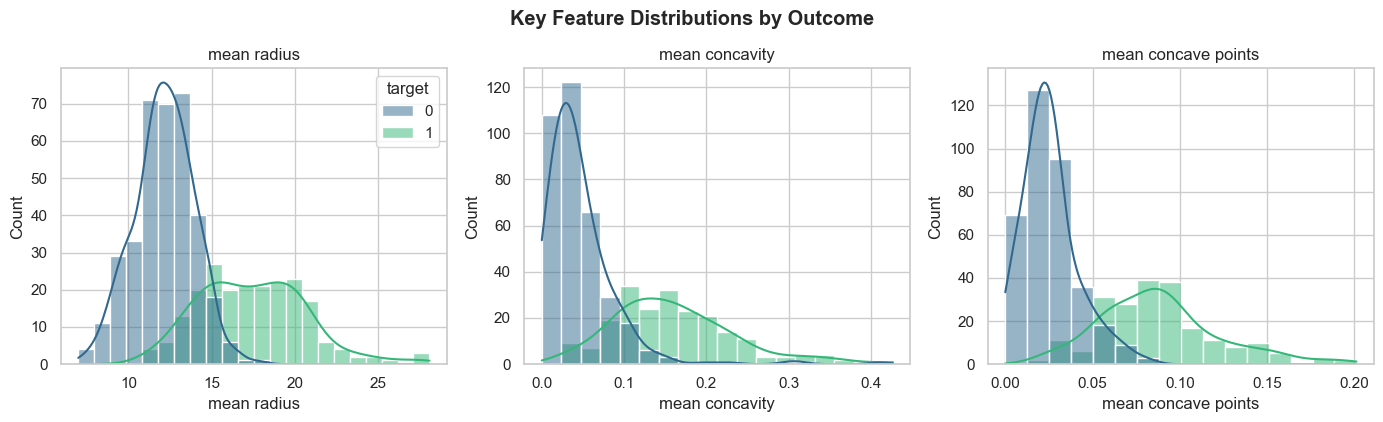

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["mean radius", "mean concavity", "mean concave points"]):
    sns.histplot(data=plot_df, x=col, hue="target", kde=True, ax=ax, palette="viridis", legend=(col == "mean radius"))
    ax.set_title(col)
plt.tight_layout()
plt.suptitle("Key Feature Distributions by Outcome", y=1.05, fontweight="bold")
plt.show()


**Observations:** Malignant tumors clearly tend to have larger radius and more irregular cell shape (`concavity`, `concave points`) — this lines up with how pathologists actually look for cancer under a microscope: larger, more irregularly-shaped cells.

## 4. Train / test split & feature scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 455, Test size: 114



## The six algorithms we'll compare

| Algorithm | Intuition | Strength |
|---|---|---|
| **Logistic Regression** | Fits a straight "decision boundary" using a weighted sum of features, squashed into a 0–1 probability. | Simple, fast, very interpretable. Good baseline. |
| **Decision Tree** | Asks a series of yes/no questions about feature values to split the data into purer and purer groups. | Easy to visualize; captures non-linear patterns. |
| **Random Forest** | Trains *many* decision trees on random subsets of data/features and averages their votes. | Reduces overfitting vs. a single tree; usually very strong. |
| **K-Nearest Neighbors (KNN)** | Looks at the *k* most similar patients (by feature distance) and takes a majority vote. | No training phase; intuitive "find similar cases" logic. |
| **Support Vector Machine (SVM)** | Finds the boundary that maximizes the margin (gap) between the two classes. | Effective in higher-dimensional feature spaces. |
| **Gradient Boosting** | Builds trees sequentially, where each new tree focuses on correcting the previous trees' mistakes. | Often the most accurate, at the cost of some interpretability. |

We will not just pick one — we'll **train all six, score them fairly on the same held-out test set, and let the data tell us which one wins.**



## How we judge the models

A single "accuracy" number can be misleading for medical data, especially when classes are imbalanced. We track five metrics:

- **Accuracy** — % of all predictions that were correct.
- **Precision** — Of everyone we *predicted* has the disease, what % actually do? (high precision = few false alarms)
- **Recall (Sensitivity)** — Of everyone who *actually* has the disease, what % did we catch? (high recall = few missed cases)
- **F1 Score** — The harmonic mean of precision and recall; a balanced single number.
- **ROC-AUC** — How well the model ranks positive cases above negative cases across *all* possible thresholds (1.0 = perfect, 0.5 = random guessing).

For medical screening tools, **recall is often the most important metric** — missing a sick patient (a false negative) is usually far more costly than a false alarm that gets ruled out with a follow-up test. We'll keep this in mind when picking our final model, not just chase the single highest number.


For cancer detection specifically, **recall matters enormously** — a missed malignant tumor (false negative) is far more dangerous than a false alarm that gets ruled out by a follow-up biopsy.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.938596,0.926829,0.904762,0.915663,0.985780
1,K-Nearest Neighbors,0.956140,0.930233,0.952381,0.941176,0.985450
2,Logistic Regression,0.929825,0.886364,0.928571,0.906977,0.984127
3,Support Vector Machine,0.956140,0.974359,0.904762,0.938272,0.982804
4,Gradient Boosting,0.947368,0.950000,0.904762,0.926829,0.979167
5,Decision Tree,0.912281,0.921053,0.833333,0.875000,0.921296


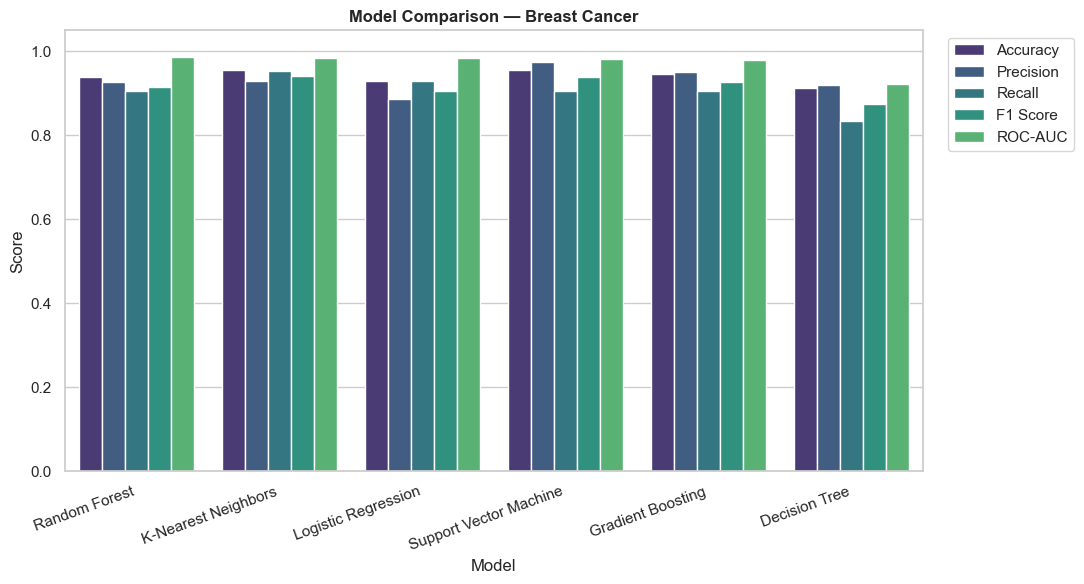

In [9]:
melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Model Comparison — Breast Cancer", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 5. Evaluate the best model in detail

Best model: Random Forest


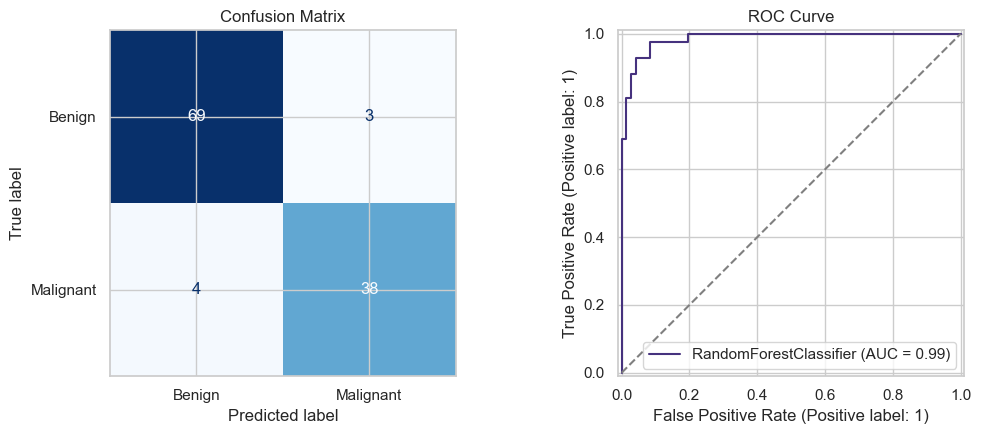

In [10]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test,
                                       display_labels=["Benign", "Malignant"],
                                       cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()


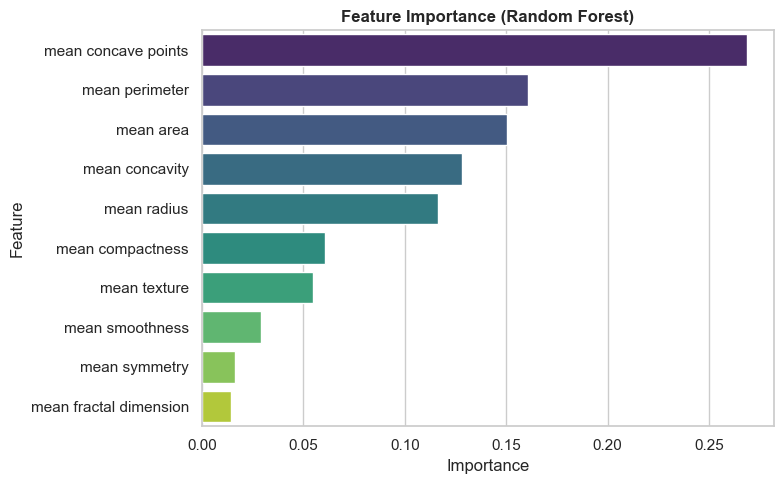

In [11]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values("Importance", ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Feature Importance ({best_name})", fontweight="bold")
    plt.tight_layout()
    plt.show()


## 6. Save the model for the web app

In [12]:
import json

joblib.dump(best_model, "../models/breast_cancer_model.joblib")
joblib.dump(scaler, "../models/breast_cancer_scaler.joblib")
with open("../models/breast_cancer_metadata.json", "w") as f:
    json.dump({
        "disease": "Breast Cancer",
        "best_model": best_name,
        "metrics": results_df.iloc[0].to_dict(),
        "class_names": ["Benign", "Malignant"],
        "feature_names": list(X.columns),
    }, f, indent=2)

print("Saved model, scaler, and metadata to ../models/")


Saved model, scaler, and metadata to ../models/



## Conclusion & next steps

- We cleaned the raw data, explored it visually, and trained **six different algorithms** under identical, fair conditions.
- **the best-performing model (see results table above)** came out on top for this dataset, balancing accuracy, recall, and ROC-AUC.
- The trained model + scaler have been saved to `models/breast_cancer_model.joblib` and `models/breast_cancer_scaler.joblib`, ready to be loaded by the Streamlit web app (`app/app.py`).

### Ideas to extend this project further
- Try hyperparameter tuning with `GridSearchCV` or `RandomizedSearchCV` to squeeze out more performance.
- Try `SMOTE` (from the `imbalanced-learn` library) if you want to address class imbalance more aggressively.
- Collect a larger, more diverse dataset — small datasets like this one risk overfitting to quirks of the sample.
- Add SHAP value explanations so the model can justify *why* it made a particular prediction (very important for medical trust).

> ⚠️ **Disclaimer:** This model is an educational/portfolio project, not a certified medical device. It should never be used for real clinical decision-making without rigorous validation, regulatory approval, and physician oversight.
